In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../../../Data/Housing_Data.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [3]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size=0.2, random_state=42)
X_train

,FireplaceQu,GarageQual
254,NaN,TA
1066,TA,TA
638,NaN,NaN
799,TA,TA
380,Gd,TA
...,...,...
1095,Gd,TA
1130,TA,TA
1294,NaN,TA
860,Gd,TA


In [5]:
def randomImpute(df,col):
    df[col][df[col].isnull()] =  df[col].dropna().sample( df[col].isnull().sum() ).values

In [6]:
df['FireplaceQu_Imputed'] = df['FireplaceQu']
df['GarageQual_Imputed'] = df['GarageQual']

In [7]:
randomImpute(df,'FireplaceQu_Imputed')
randomImpute(df,'GarageQual_Imputed')

C:\Users\Jehan\AppData\Local\Temp\ipykernel_8324\3451002863.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df[col][df[col].isnull()] =  df[col].dropna().sample( df[col].isnull().sum() ).values


# Check Distribution
## 1) Check barplot

<Axes: xlabel='GarageQual_Imputed'>

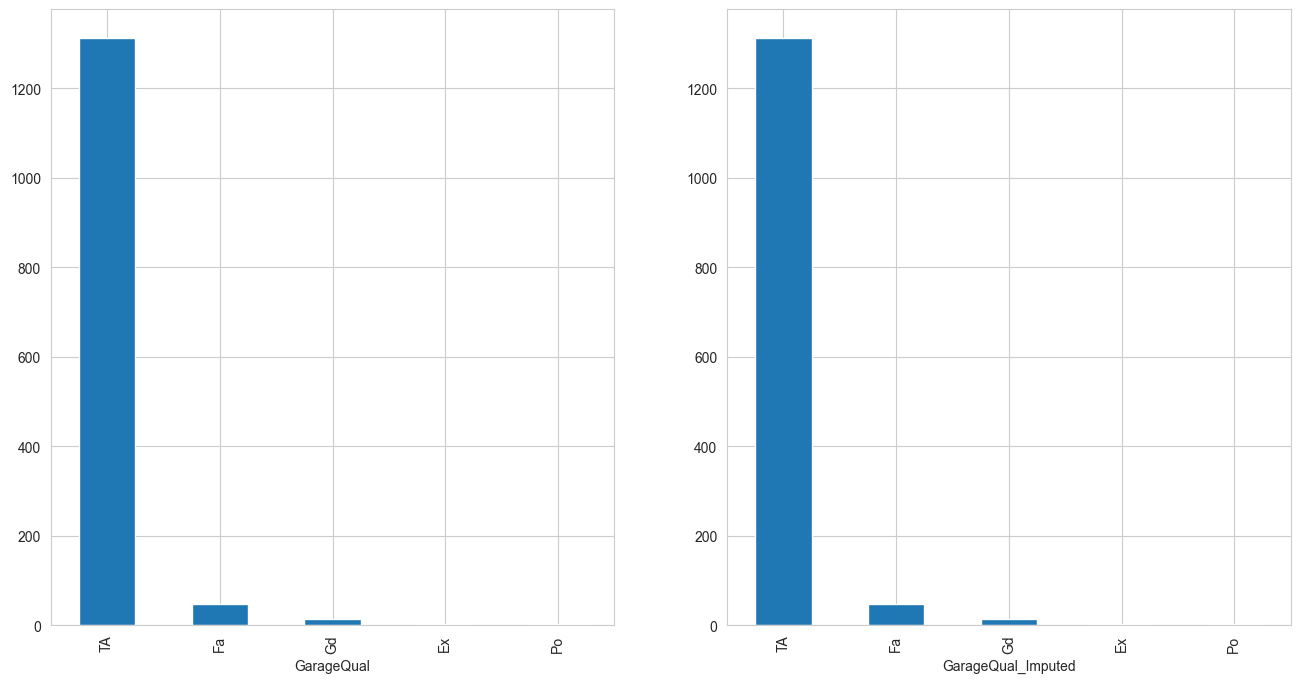

In [12]:
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(16,8))
df['GarageQual'].value_counts().plot(kind='bar', ax=ax[0])
df['GarageQual_Imputed'].value_counts().plot(kind='bar', ax=ax[1])

<Axes: xlabel='FireplaceQu_Imputed'>

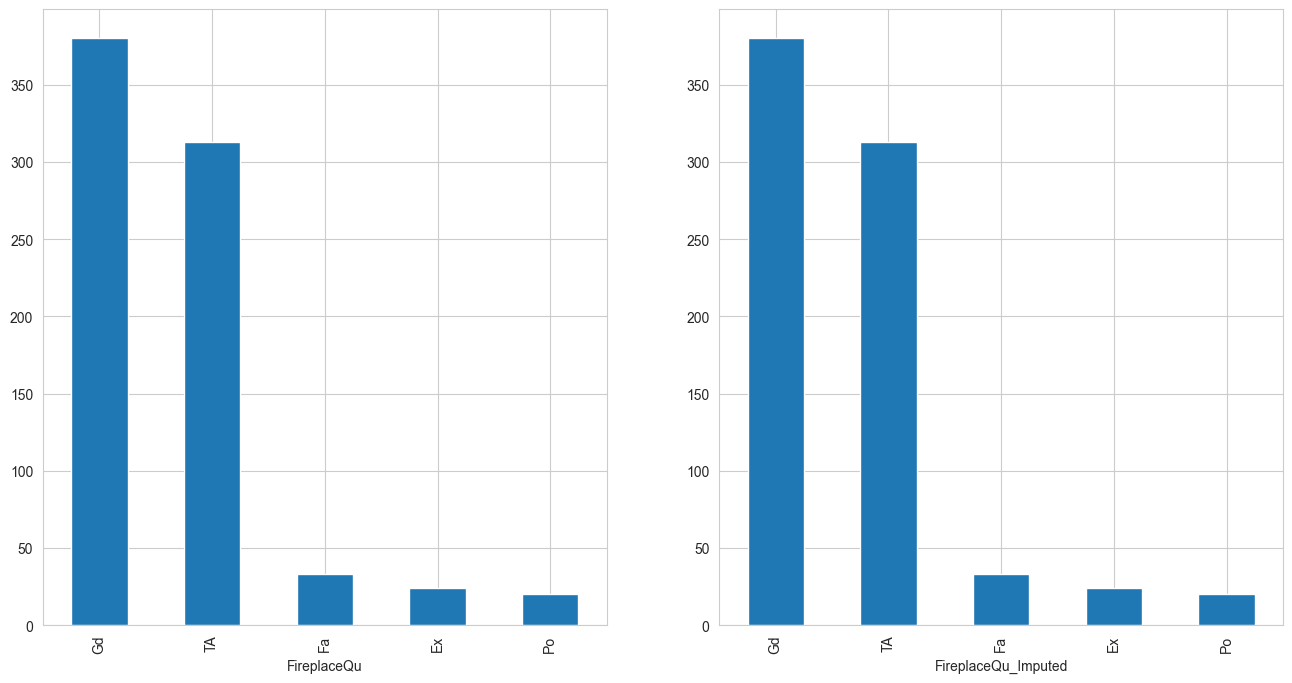

In [13]:
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(16,8))
df['FireplaceQu'].value_counts().plot(kind='bar', ax=ax[0])
df['FireplaceQu_Imputed'].value_counts().plot(kind='bar', ax=ax[1])

In [ ]:
## 2. Check

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class RandomImputer(BaseEstimator, TransformerMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state

    def fit(self, X, y=None):
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            missing = X[col].isnull()
            if missing.sum() > 0:
                observed_values = X.loc[~missing, col]
                
                if len(observed_values) > 0:
                    X.loc[missing, col] = self.rng_.choice(
                        observed_values, size=missing.sum(), replace=True
                    )
        return X